In [4]:
pip install opencv-python scikit-learn numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import cv2
import numpy as np

dataset_path = r"C:\Users\C Siddharth Reddy\Indian_Dance\train"

data = []
labels = []

img_size = 64

for category in os.listdir(dataset_path):

    category_path = os.path.join(dataset_path, category)

    if not os.path.isdir(category_path):
        continue

    for img in os.listdir(category_path):

        img_path = os.path.join(category_path, img)

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (img_size, img_size))

        data.append(image.flatten())
        labels.append(category)

data = np.array(data)
labels = np.array(labels)

print("Images loaded:", len(data))
print("Classes:", np.unique(labels))

Images loaded: 364
Classes: ['bharatanatyam' 'kathak' 'kathakali' 'kuchipudi' 'manipuri'
 'mohiniyattam' 'odissi' 'sattriya']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score

print("KNN:", accuracy_score(y_test, pred_knn))
print("Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Decision Tree:", accuracy_score(y_test, pred_dt))
print("Random Forest:", accuracy_score(y_test, pred_rf))

KNN: 0.2602739726027397
Logistic Regression: 0.5342465753424658
Decision Tree: 0.273972602739726
Random Forest: 0.547945205479452


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_test, y_pred, model_name):

    print("\n", model_name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


evaluate_model(y_test, pred_knn, "KNN")
evaluate_model(y_test, pred_lr, "Logistic Regression")
evaluate_model(y_test, pred_dt, "Decision Tree")
evaluate_model(y_test, pred_rf, "Random Forest")


 KNN
Accuracy: 0.2602739726027397
Precision: 0.21541296162781381
Recall: 0.2602739726027397
F1 Score: 0.22520547945205477
Confusion Matrix:
[[7 3 0 1 0 2 0 0]
 [2 4 0 1 2 0 1 1]
 [1 1 0 1 4 0 3 0]
 [1 0 0 1 1 0 1 0]
 [0 0 0 2 3 1 0 0]
 [0 2 0 2 4 2 0 0]
 [2 2 0 0 2 0 2 0]
 [2 3 0 1 3 1 1 0]]

 Logistic Regression
Accuracy: 0.5342465753424658
Precision: 0.5923026744944554
Recall: 0.5342465753424658
F1 Score: 0.5499242574644599
Confusion Matrix:
[[7 0 0 3 1 0 0 2]
 [1 7 0 0 0 1 0 2]
 [0 0 7 1 1 0 0 1]
 [0 0 0 1 1 1 0 1]
 [0 2 0 0 4 0 0 0]
 [1 1 1 0 1 5 0 1]
 [0 1 0 2 0 0 4 1]
 [3 0 0 0 1 3 0 4]]

 Decision Tree
Accuracy: 0.273972602739726
Precision: 0.3479214849077863
Recall: 0.273972602739726
F1 Score: 0.29079034117415725
Confusion Matrix:
[[5 1 0 2 0 1 2 2]
 [0 3 2 0 2 1 1 2]
 [1 1 1 2 1 1 1 2]
 [0 0 0 0 3 0 0 1]
 [0 0 0 2 3 1 0 0]
 [0 1 3 1 0 4 1 0]
 [0 1 1 1 1 1 3 0]
 [0 1 0 4 1 3 1 1]]

 Random Forest
Accuracy: 0.547945205479452
Precision: 0.579646076906351
Recall: 0.54794520547945

C:\Users\C Siddharth Reddy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

models = {
    "KNN": pred_knn,
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf
}

for name, pred in models.items():

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="weighted")
    rec = recall_score(y_test, pred, average="weighted")
    f1 = f1_score(y_test, pred, average="weighted")

    results[name] = [acc, prec, rec, f1]

    print("\n", name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)


 KNN
Accuracy: 0.2602739726027397
Precision: 0.21541296162781381
Recall: 0.2602739726027397
F1 Score: 0.22520547945205477

 Logistic Regression
Accuracy: 0.5342465753424658
Precision: 0.5923026744944554
Recall: 0.5342465753424658
F1 Score: 0.5499242574644599

 Decision Tree
Accuracy: 0.273972602739726
Precision: 0.3479214849077863
Recall: 0.273972602739726
F1 Score: 0.29079034117415725

 Random Forest
Accuracy: 0.547945205479452
Precision: 0.579646076906351
Recall: 0.547945205479452
F1 Score: 0.5561357693955418


C:\Users\C Siddharth Reddy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


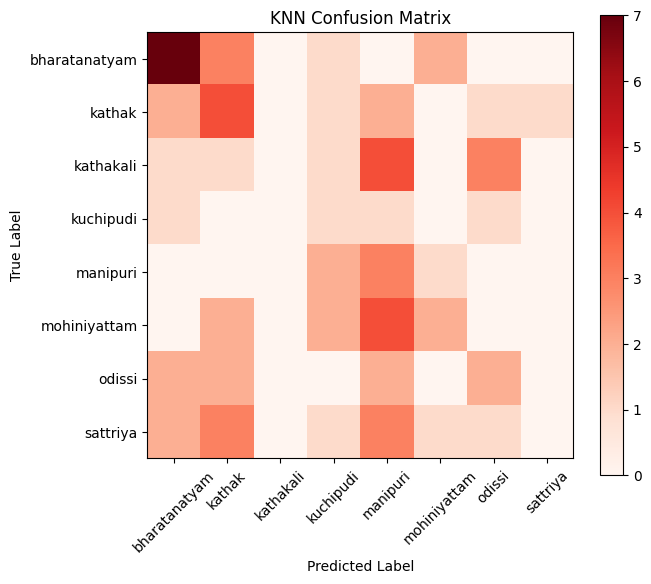

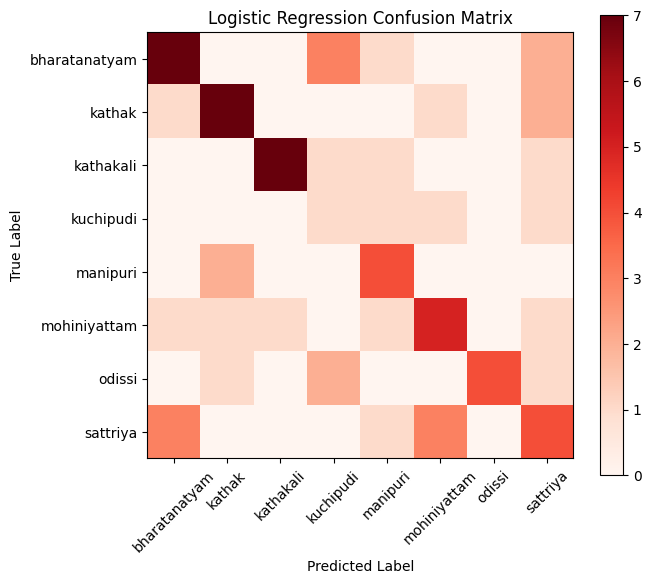

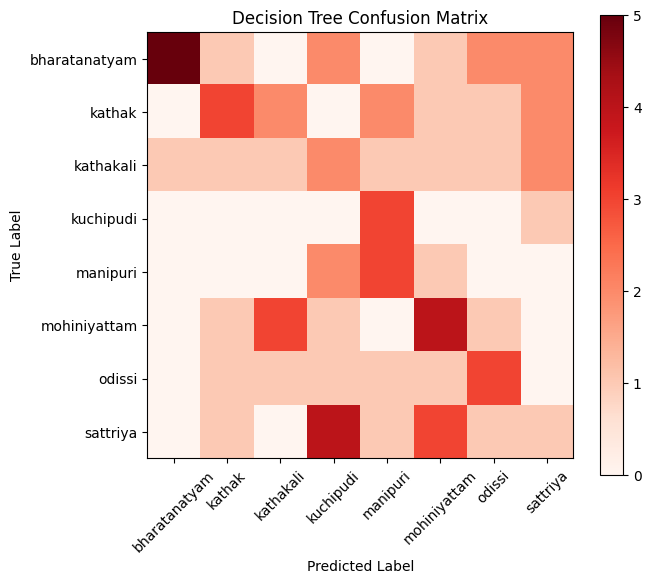

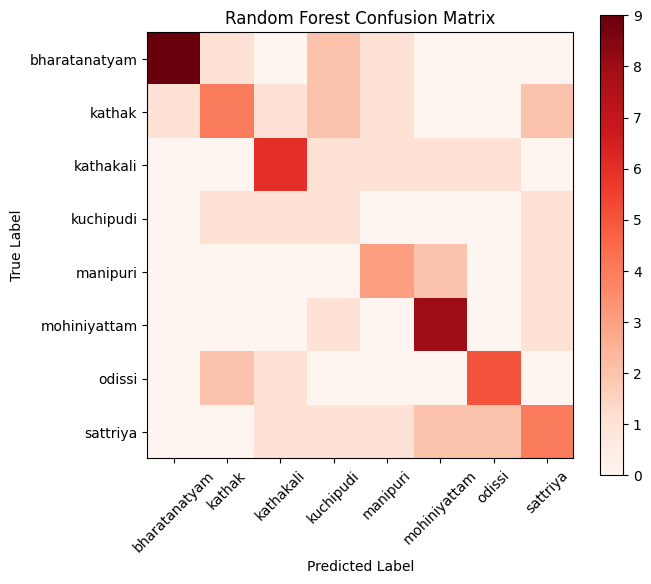

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

classes = np.unique(labels)

models = {
    "KNN": pred_knn,
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf
}

for model_name, y_pred in models.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7,6))
    plt.imshow(cm, cmap="Reds")   # Red color map
    plt.title(model_name + " Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()

    # Save image
    plt.savefig(model_name.replace(" ","_")+"_confusion_matrix_red.png")

    plt.show()